In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Your Name and PRN:
- Name: ______________________
- PRN : ______________________
- Date: ______________________

# Deep Neural Network
## Assignment A04

## Tensor Flow
- Select number of layers
- Select node in each of the layers
- Choose activation function
- multi-class - Fashion MNIST dataset (all 60000 images)
- Implement one or more of following to achieve max accuracy.
    - L1/ L2 Regularization
    - Dropout
    - Batch Normalization
    - Early stopping
- Save model

In [2]:
###-----------------
### Import Libraries
###-----------------
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf

from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix

In [3]:
###-----------------
### Global Variables
###-----------------
inpDir   = r'D:\Deep_Learning\SharedData'
outDir   = '../output'
modelDir = '../models'
subDir   = 'fashion_mnist'
altName  = 'A04_fashion_cnn'

RANDOM_STATE = 24
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 8),
          'axes.labelsize': 'large',
          'axes.titlesize': 'x-large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large'
         }

CMAP = 'brg'
plt.rcParams.update(params)
plt.style.use('seaborn-v0_8-darkgrid')

In [ ]:
###-----------------
### Hyper Parameters
###-----------------
EPOCHS     = 60       # number of epochs
ALPHA      = 0.0005    # learning rate
BATCH_SIZE = 64       # mini batch size
PATIENCE   = 15 

In [5]:
physical_devices = tf.config.list_logical_devices('GPU')

if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)

print(tf.__version__, physical_devices)

2.21.0 []


## Helper Functions

In [6]:
def fn_plot_labels(train_df, test_df):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    train_df['label'].value_counts().plot(kind='bar',
                                          title='Train',
                                          color='DarkBlue',
                                          alpha=0.7)

    plt.subplot(1, 2, 2)
    test_df['label'].value_counts().plot(kind='bar',
                                         title='Test',
                                         color='Orange',
                                         alpha=0.7)
    plt.tight_layout()
    plt.show()

## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images.

In [7]:
#class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names = {0: 'T-shirt/top', 1: 'Trouser',   2: 'Pullover', 3: 'Dress', 4: 'Coat',
               5: 'Sandal',      6: 'Shirt',      7: 'Sneaker',  8: 'Bag',   9: 'Ankle boot'}

In [8]:
train_filename = os.path.join(inpDir, 'fashion-mnist_train.csv')  
test_filename  = os.path.join(inpDir, 'fashion-mnist_test.csv') 

train_df = pd.read_csv(train_filename, header=0)
test_df  = pd.read_csv(test_filename,  header=0)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

Train shape: (60000, 785)
Test shape : (10000, 785)


In [10]:
def split_feature_label(row_dict):
    label = row_dict.pop('label')

    # Stack 784 pixel values → reshape to (28, 28, 1) for CNN
    features = tf.cast(tf.stack(list(row_dict.values())), tf.float32)
    features = tf.reshape(features, (28, 28, 1))

    return features, label

In [11]:
tmp_ds   = tf.data.Dataset.from_tensor_slices(dict(train_df))
train_ds = tmp_ds.map(split_feature_label)

train_ds = train_ds.cache()
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

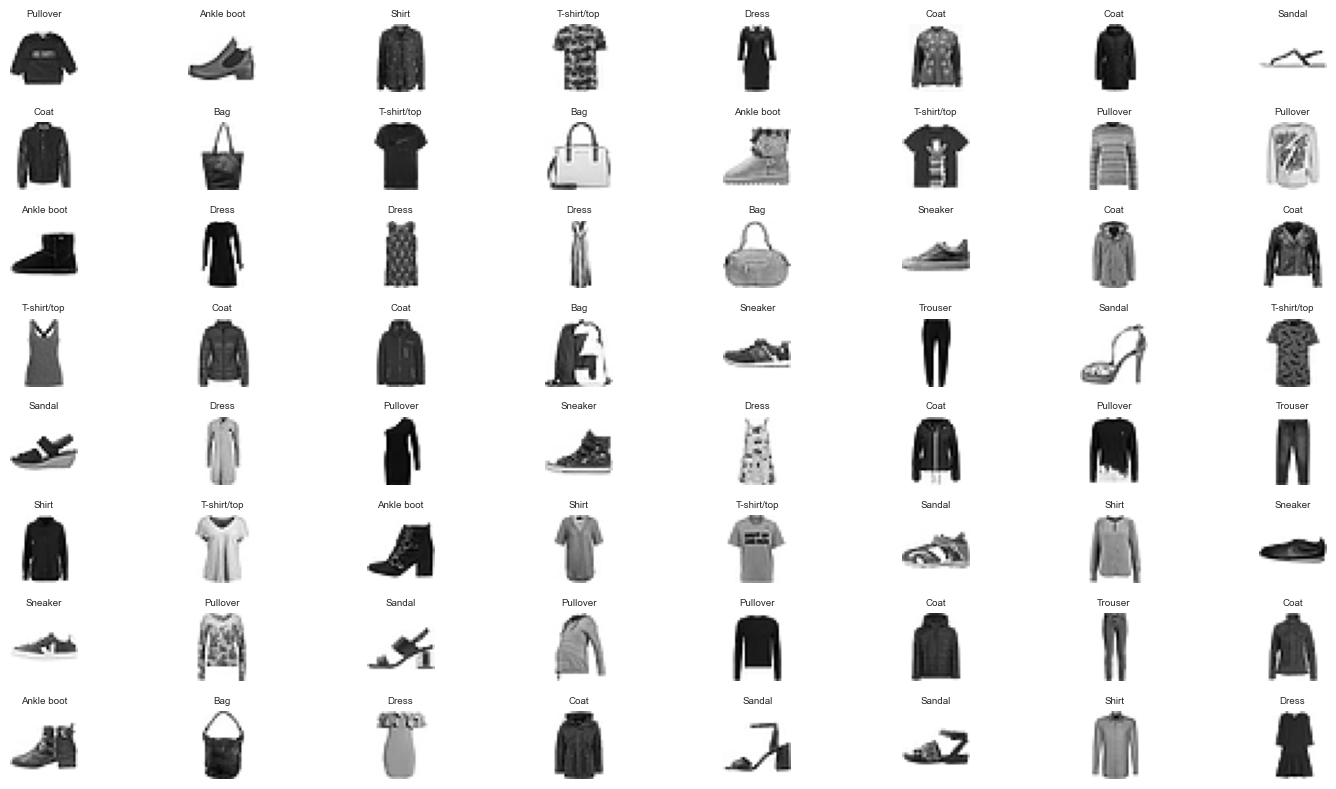

In [12]:
for images, labels in train_ds.take(1):
    for i in range(BATCH_SIZE):
        plt.subplot(BATCH_SIZE // 8, 8, i + 1)
        plt.grid(False)
        plt.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary)
        plt.title(class_names[labels[i].numpy()], fontsize=7)
        plt.axis('off')
plt.tight_layout()

In [13]:
tmp_ds  = tf.data.Dataset.from_tensor_slices(dict(test_df))
test_ds = tmp_ds.map(split_feature_label)

test_ds = test_ds.cache()
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Define Model

### Architecture
```
Input: 28 x 28 x 1 (grayscale)

Set 1: Conv2D(32, 3x3, same) → BatchNorm → ReLU → MaxPool(2,2) → Dropout(0.1)  → 14x14x32
Set 2: Conv2D(64, 3x3)       → BatchNorm → ReLU → MaxPool(2,2) → Dropout(0.2)  →  6x6x64
Set 3: Conv2D(128, 3x3)      → BatchNorm → ReLU              → Dropout(0.3)  →  4x4x128

Flatten → 2048
Dense(128) → BatchNorm → ReLU → Dropout(0.4)
Dense(10)  → logits
```

In [ ]:
from tensorflow.keras import regularizers
krnal_init = tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)

input_shape = (28, 28, 1)


dor1 = 0.2
dor2 = 0.3
dor3 = 0.3
dor4 = 0.4

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=input_shape))
model.add(tf.keras.layers.Rescaling(1./255.))

# Set 1
model.add(tf.keras.layers.Conv2D(32, (3,3),
                                 kernel_initializer=krnal_init,
                                 padding='same'))          # (28 x 28 x 32)
model.add(tf.keras.layers.BatchNormalization())           
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool2D())                     # (14 x 14 x 32)
model.add(tf.keras.layers.Dropout(rate=dor1))

# Set 2
model.add(tf.keras.layers.Conv2D(64, (3,3),
                                 kernel_initializer=krnal_init))   # (12 x 12 x 64)
model.add(tf.keras.layers.BatchNormalization())            
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool2D())                     # (6 x 6 x 64)
model.add(tf.keras.layers.Dropout(rate=dor2))

# Set 3
model.add(tf.keras.layers.Conv2D(128, (3,3),
                                 kernel_initializer=krnal_init))   # (4 x 4 x 128)
model.add(tf.keras.layers.BatchNormalization())           
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.Dropout(rate=dor3))

### Head
model.add(tf.keras.layers.Flatten())                       # (2048)

# Dense 1 — add L2
model.add(tf.keras.layers.Dense(128,
                                kernel_initializer=krnal_init,
                                kernel_regularizer=regularizers.l2(1e-4)))  
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.Dropout(rate=dor4))

# Dense 2 — output logits
model.add(tf.keras.layers.Dense(10,
                                kernel_initializer=krnal_init))    # (10)

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,642 (1.36 MB)

 Trainable params: 356,938 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

None


In [ ]:
loss_fn   = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate=ALPHA,
                                     clipnorm = 1.0)

model.compile(optimizer=optimizer,
              loss=loss_fn,
              metrics=['accuracy'])

## Callbacks — Early Stopping

In [ ]:
# ── Model checkpoint ──
os.makedirs(os.path.join(modelDir, subDir), exist_ok=True)
checkpoint_filepath = os.path.join(modelDir, subDir, f'{altName}.weights.h5')

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True
)

# ── Early stopping ──
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    mode='auto',
    restore_best_weights=True
)

# ── Reduce LR on plateau ──
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

In [17]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stopping_callback,
               model_checkpoint_callback,
               reduce_lr_callback]
)

Epoch 1/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 50s 48ms/step - accuracy: 0.8232 - loss: 0.4952 - val_accuracy: 0.8962 - val_loss: 0.2808 - learning_rate: 0.0010
Epoch 2/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8790 - loss: 0.3339 - val_accuracy: 0.8983 - val_loss: 0.2760 - learning_rate: 0.0010
Epoch 3/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.8929 - loss: 0.2987 - val_accuracy: 0.9093 - val_loss: 0.2412 - learning_rate: 0.0010
Epoch 4/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9007 - loss: 0.2745 - val_accuracy: 0.9198 - val_loss: 0.2200 - learning_rate: 0.0010
Epoch 5/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9050 - loss: 0.2594 - val_accuracy: 0.9212 - val_loss: 0.2132 - learning_rate: 0.0010
Epoch 6/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9112 - loss: 0.2430 - val_accuracy: 0.9126 - val_loss: 0.2344 - learning_rate: 0.0010
Epoch 7/30
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9145 - l

In [18]:
loss_df = pd.DataFrame(history.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.823200,0.495246,0.8962,0.280846,0.001
1,0.878967,0.333948,0.8983,0.276042,0.001
2,0.892900,0.298664,0.9093,0.241228,0.001
3,0.900733,0.274475,0.9198,0.219998,0.001
4,0.904967,0.259353,0.9212,0.213173,0.001


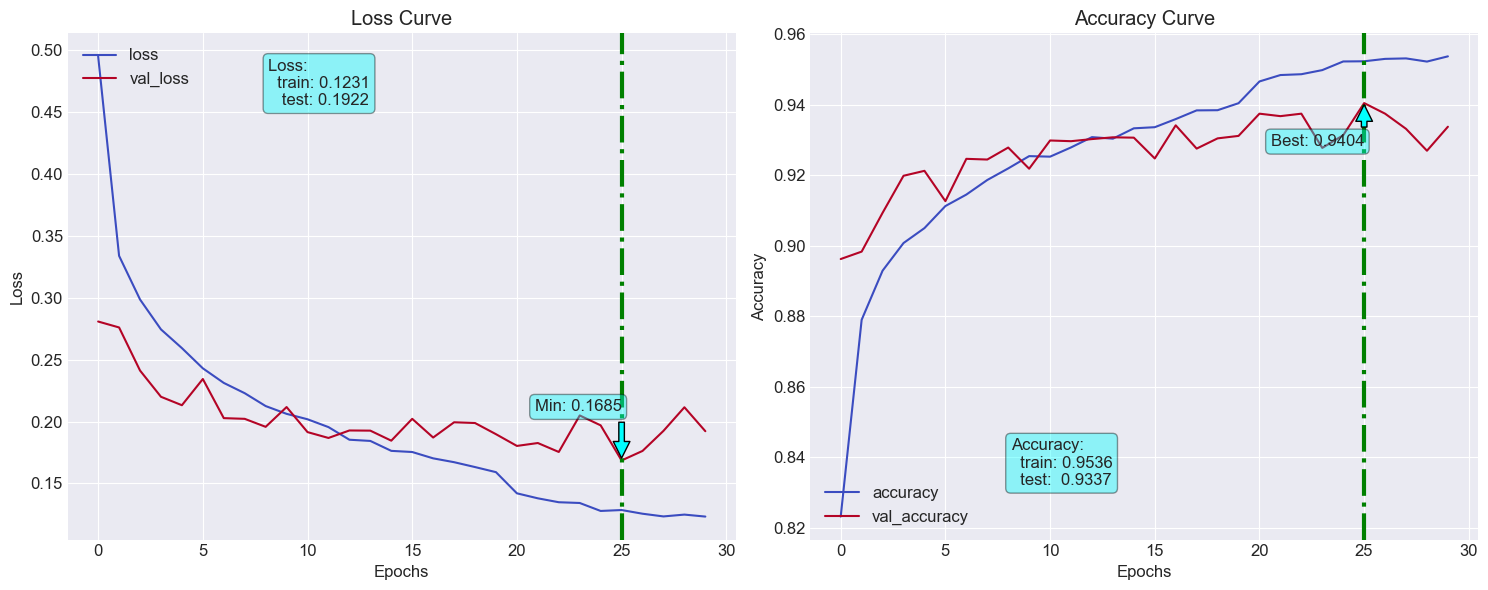

In [19]:
fn_plot_tf_hist(loss_df)

## Prediction on Train dataset

In [20]:
y_true, y_pred = [], []

for features, labels in train_ds:
    pred = model(features, training=False)
    pred = pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())

y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

accuracy_score(y_true, y_pred)

0.9756

In [21]:
print(classification_report(y_true, y_pred, target_names=list(class_names.values())))

              precision    recall  f1-score   support

 T-shirt/top       0.94      0.96      0.95      6000
     Trouser       1.00      1.00      1.00      6000
    Pullover       0.97      0.95      0.96      6000
       Dress       0.97      0.99      0.98      6000
        Coat       0.95      0.98      0.96      6000
      Sandal       1.00      1.00      1.00      6000
       Shirt       0.95      0.90      0.92      6000
     Sneaker       0.99      0.99      0.99      6000
         Bag       1.00      1.00      1.00      6000
  Ankle boot       0.99      0.99      0.99      6000

    accuracy                           0.98     60000
   macro avg       0.98      0.98      0.98     60000
weighted avg       0.98      0.98      0.98     60000



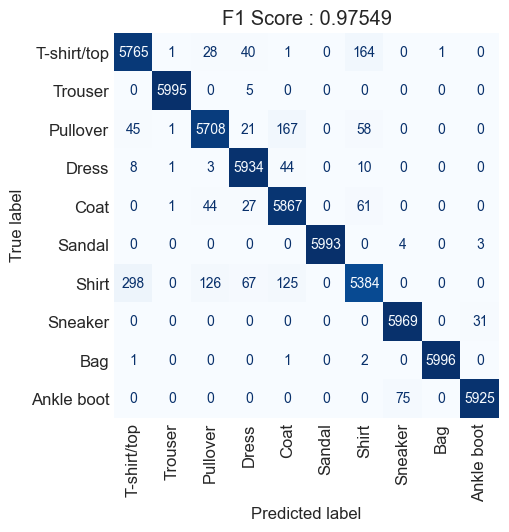

In [22]:
fn_plot_confusion_matrix(y_true, y_pred, labels=class_names)

## Prediction on Test dataset

In [23]:
y_true, y_pred = [], []

for features, labels in test_ds:
    pred = model(features, training=False)
    pred = pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())

y_true, y_pred = np.concatenate(y_true), np.concatenate(y_pred)

accuracy_score(y_true, y_pred)

0.9404

In [24]:
print(classification_report(y_true, y_pred, target_names=list(class_names.values())))

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.92      0.90      1000
     Trouser       0.99      1.00      0.99      1000
    Pullover       0.93      0.89      0.91      1000
       Dress       0.93      0.95      0.94      1000
        Coat       0.89      0.93      0.91      1000
      Sandal       0.99      0.98      0.99      1000
       Shirt       0.85      0.80      0.83      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       1.00      0.99      0.99      1000
  Ankle boot       0.97      0.98      0.98      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



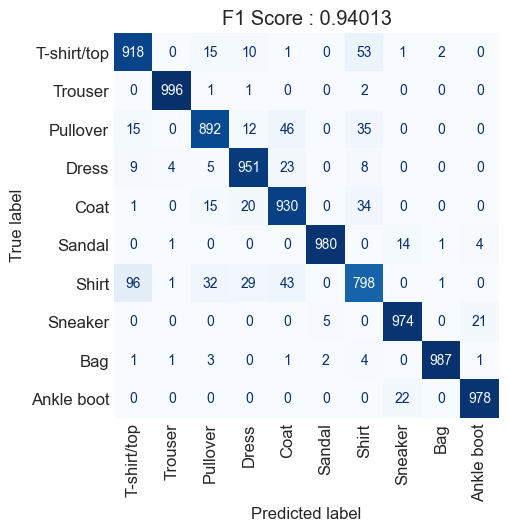

In [25]:
fn_plot_confusion_matrix(y_true, y_pred, labels=class_names)

## Save Model

In [26]:
# save_path = os.path.join(modelDir, subDir, f'{altName}.keras')
# model.save(save_path)
# print(f'Model saved to: {save_path}')